In [1]:
import sys
!{sys.executable} -m pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 --force-reinstall

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (2449.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-win_amd64.whl (6.1 MB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached https://download.pytorch.org/whl/setuptools-70.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using ca


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install timm

%pip install livelossplot

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


FASE 1

In [4]:
import torchvision.transforms as T
from torch import nn
from helpers import *
from lr_finder import lr_finder
import matplotlib.pyplot as plt
import os
import numpy as np


In [5]:
#Ubicacion de las fotos para entrenamiento
ruta_train = os.path.join("landmark_images", "train") 

In [6]:
from torchvision import datasets
from torch.utils.data import DataLoader

# 1. Configuramos fotos de 'test'
transformaciones_test = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.4638, 0.4727, 0.4687], std=[0.2701, 0.2712, 0.3024])
])

# 2. Ubicacion de la carpeta 'test'
ruta_test = os.path.join("landmark_images", "test")
dataset_test = datasets.ImageFolder(ruta_test, transform=transformaciones_test)

# 3. DataLoader para el test
data_loaders = {}
data_loaders['test'] = DataLoader(dataset_test, batch_size=32, shuffle=False, num_workers=0)

print(f"¡Examen preparado! Total de fotos para evaluar: {len(dataset_test)}")

¡Examen preparado! Total de fotos para evaluar: 1270


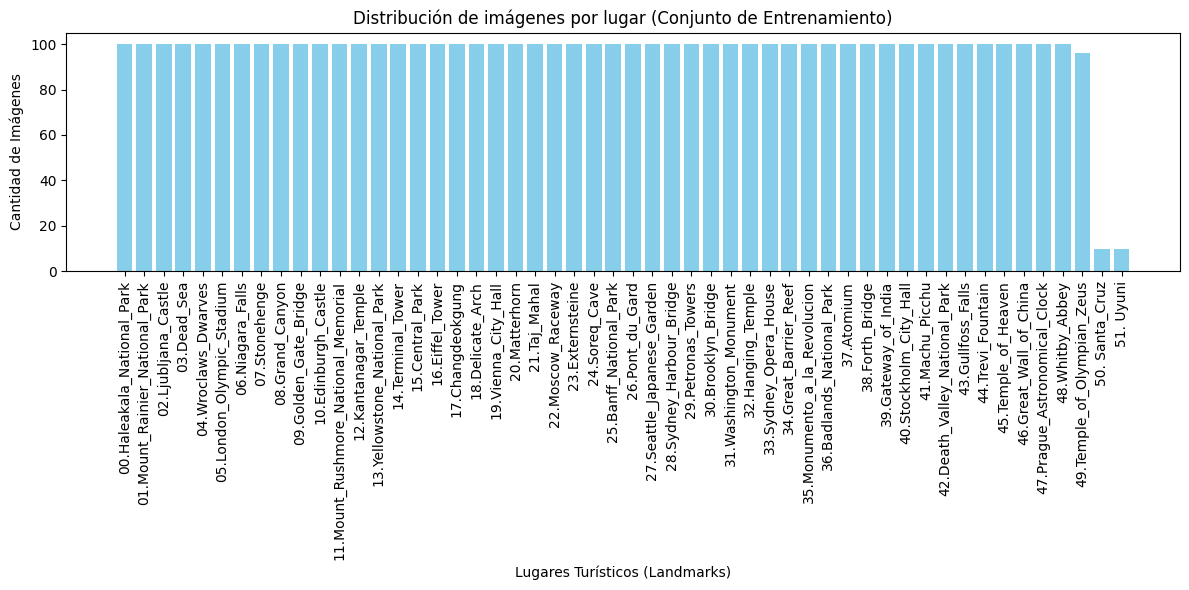

In [8]:
# Contar cantidad fotos hay en cada subcarpeta
nombres_lugares = []
cantidad_fotos = []

# Revisar cada carpeta dentro de 'train'
for carpeta in os.listdir(ruta_train):
    ruta_carpeta = os.path.join(ruta_train, carpeta)
    if os.path.isdir(ruta_carpeta): 
        nombres_lugares.append(carpeta)
        num_fotos = len(os.listdir(ruta_carpeta))
        cantidad_fotos.append(num_fotos)

# Dibujar el gráfico de barras
plt.figure(figsize=(12, 6)) 
plt.bar(nombres_lugares, cantidad_fotos, color='skyblue')

#títulos 
plt.xlabel('Lugares Turísticos (Landmarks)')
plt.ylabel('Cantidad de Imágenes')
plt.title('Distribución de imágenes por lugar (Conjunto de Entrenamiento)')
plt.xticks(rotation=90) 

plt.tight_layout()
plt.show()

In [9]:
data_loaders = get_data_loaders(batch_size=32, rand_augment_magnitude=15, num_workers=0)

Reusing cached mean and std
Dataset mean: tensor([0.4638, 0.4727, 0.4687]), std: tensor([0.2701, 0.2712, 0.3024])
Reusing cached mean and std


c:\Users\Patricia\Modulo 2\RN_PROYT1\helpers.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(cache_file)


['00.Haleakala_National_Park', '01.Mount_Rainier_National_Park', '02.Ljubljana_Castle', '03.Dead_Sea', '04.Wroclaws_Dwarves', '05.London_Olympic_Stadium', '06.Niagara_Falls', '07.Stonehenge', '08.Grand_Canyon', '09.Golden_Gate_Bridge', '10.Edinburgh_Castle', '11.Mount_Rushmore_National_Memorial', '12.Kantanagar_Temple', '13.Yellowstone_National_Park', '14.Terminal_Tower', '15.Central_Park', '16.Eiffel_Tower', '17.Changdeokgung', '18.Delicate_Arch', '19.Vienna_City_Hall', '20.Matterhorn', '21.Taj_Mahal', '22.Moscow_Raceway', '23.Externsteine', '24.Soreq_Cave', '25.Banff_National_Park', '26.Pont_du_Gard', '27.Seattle_Japanese_Garden', '28.Sydney_Harbour_Bridge', '29.Petronas_Towers', '30.Brooklyn_Bridge', '31.Washington_Monument', '32.Hanging_Temple', '33.Sydney_Opera_House', '34.Great_Barrier_Reef', '35.Monumento_a_la_Revolucion', '36.Badlands_National_Park', '37.Atomium', '38.Forth_Bridge', '39.Gateway_of_India', '40.Stockholm_City_Hall', '41.Machu_Picchu', '42.Death_Valley_National_Pa

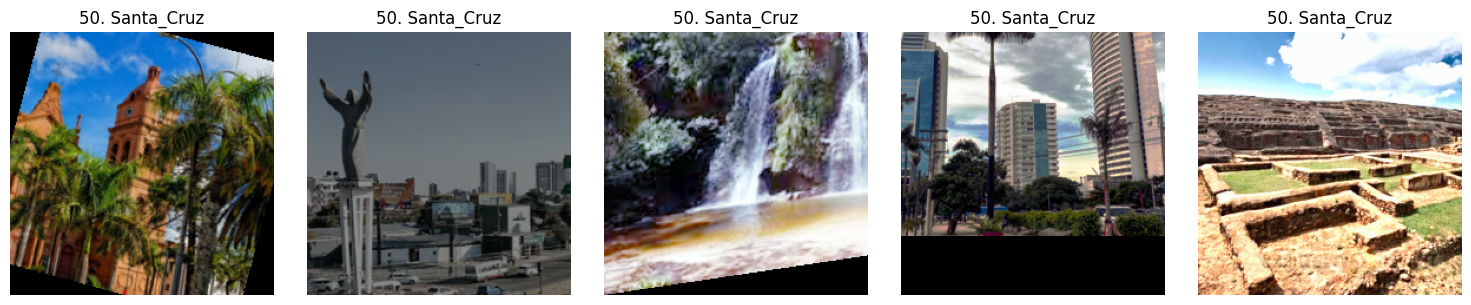

In [11]:
#Buscar carpeta de Santa Cruz 
clase_buscada = "50. Santa_Cruz"

#Obtenemos el dataset y la lista de todos los nombres
dataset_entrenamiento = data_loaders['train'].dataset
nombres_clases = dataset_entrenamiento.classes

print(nombres_clases)

# Buscamos el número de etiqueta que le asignó PyTorch a esa clase
indice_buscado = nombres_clases.index(clase_buscada)

# 3. Buscamos foto por foto hasta juntar 5 de Santa Cruz
fotos_encontradas = []
for foto, etiqueta in dataset_entrenamiento:
    if etiqueta == indice_buscado:
        fotos_encontradas.append(foto)
    if len(fotos_encontradas) == 5: 
        break

# 4. Preparamos el lienzo para dibujarlas
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
   
    img = fotos_encontradas[i].numpy().transpose((1, 2, 0))
    
    mean = np.array([0.4638, 0.4727, 0.4687])
    std = np.array([0.2701, 0.2712, 0.3024])
    img = std * img + mean
    img = np.clip(img, 0, 1) 
    
   
    axes[i].imshow(img)
    axes[i].set_title(clase_buscada)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

FASE 2

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

print(f"¿Pytorch ve la GPU?: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Tarjeta detectada: {torch.cuda.get_device_name(0)}")

¿Pytorch ve la GPU?: True
Tarjeta detectada: NVIDIA GeForce RTX 4060 Laptop GPU


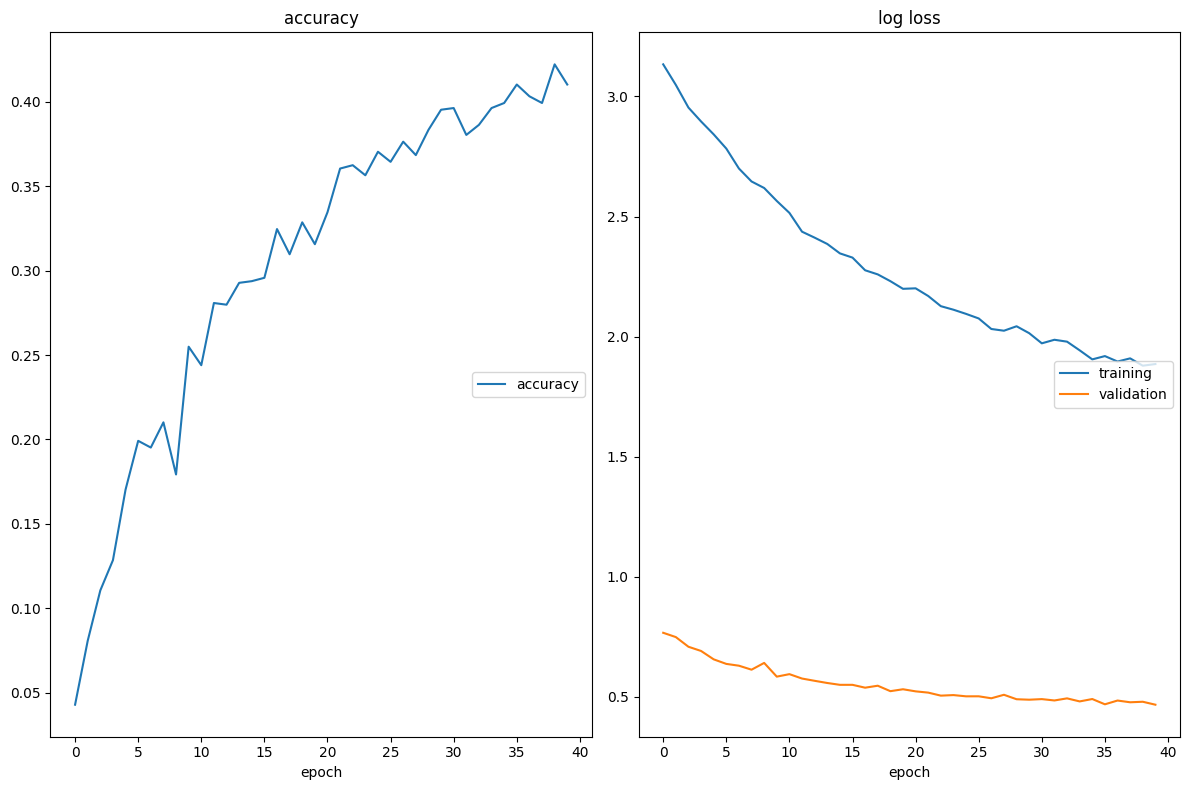

accuracy
	accuracy         	 (min:    0.043, max:    0.422, cur:    0.410)
log loss
	training         	 (min:    1.879, max:    3.133, cur:    1.886)
	validation       	 (min:    0.468, max:    0.767, cur:    0.468)


In [18]:
from livelossplot import PlotLosses 

# 1. arquitectura
class MiRedLandmark(nn.Module):
    def __init__(self, num_clases):
        super(MiRedLandmark, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 28 * 28, 500)
        self.fc2 = nn.Linear(500, num_clases)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 28 * 28)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 2. CONFIGURACIÓN 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_clases = len(data_loaders['train'].dataset.classes)
modelo_3capas = MiRedLandmark(num_clases).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(modelo_3capas.parameters(), lr=0.001) 
save_path = 'modelo_3capas.pt'

# 3. ENTRENAMIENTO y VALIDACIÓN 
liveloss = PlotLosses()
epochs = 40
valid_loss_min = float('inf')

for epoch in range(1, epochs + 1):
    train_loss = 0.0
    valid_loss = 0.0
    correct = 0
    total = 0
    
    modelo_3capas.train()
    for data, target in data_loaders['train']:
        data, target = data.to(device), target.to(device) 
        optimizer.zero_grad()
        output = modelo_3capas(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * data.size(0)
        
    # VALIDACIÓN
    modelo_3capas.eval()
    with torch.no_grad():
        for data, target in data_loaders['valid']:
            data, target = data.to(device), target.to(device)
            output = modelo_3capas(data)
            loss = criterion(output, target)
            valid_loss += loss.item() * data.size(0)
            
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    # Promedios
    train_loss = train_loss / len(data_loaders['train'].dataset)
    valid_loss = valid_loss / len(data_loaders['valid'].dataset)
    accuracy = correct / total

    # Guardar
    if valid_loss <= valid_loss_min:
        torch.save(modelo_3capas.state_dict(), save_path)
        valid_loss_min = valid_loss
    
    # Gráficas
    liveloss.update({'log loss': train_loss, 'val_log loss': valid_loss, 'accuracy': accuracy})
    liveloss.send()

In [20]:
import os
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Preparamos las transformaciones para el conjunto de prueba
transformaciones_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

ruta_test = os.path.join("landmark_images", "test")
dataset_test = datasets.ImageFolder(ruta_test, transform=transformaciones_test)
data_loaders['test'] = DataLoader(dataset_test, batch_size=32, shuffle=False, num_workers=0)



In [21]:
def test_modelo(model, loaders, criterion):
    test_loss = 0.
    correct = 0.
    total = 0.

    model.eval() 
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(loaders['test']):
            data, target = data.to(device), target.to(device)
            
            output = model(data)
            loss = criterion(output, target)
            test_loss = test_loss + ((1 / (batch_idx + 1)) * (loss.data.item() - test_loss))
            
            pred = output.data.max(1, keepdim=True)[1]
            correct += np.sum(np.squeeze(pred.eq(target.data.view_as(pred))).cpu().numpy())
            total += data.size(0)
            
    print('Test Loss: {:.6f}\n'.format(test_loss))
    print('\nTest Accuracy: %2d%% (%2d/%2d)' % (
        100. * correct / total, correct, total))

# Cargar el mejor entrenamiento que se guardó y probarlo en el conjunto de prueba
modelo_3capas.load_state_dict(torch.load('modelo_3capas.pt'))
test_modelo(modelo_3capas, data_loaders, criterion)

C:\Users\Patricia\AppData\Local\Temp\ipykernel_1636\1720445503.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelo_3capas.load_state_dict(torch.load('modelo_3capas.p

Test Loss: 2.405214


Test Accuracy: 42% (545/1270)


In [22]:
# Punto 6
modelo_3capas.load_state_dict(torch.load('modelo_3capas.pt'))
modelo_3capas.to('cpu') 
modelo_3capas.eval()

# 2. Convertimos el modelo
modelo_script = torch.jit.script(modelo_3capas)

# 3. Guardamos el archivo final
modelo_script.save("modelo_3capas_script.pt")

print("Modelo exportado exitosamente como 'modelo_3capas_script.pt'")

C:\Users\Patricia\AppData\Local\Temp\ipykernel_1636\4098104339.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  modelo_3capas.load_state_dict(torch.load('modelo_3capas.pt

Modelo exportado exitosamente como 'modelo_3capas_script.pt'


FASE 3

1. Seleccionar dos modelos preentrenado de torchvision (ResNet18, ResNet50, VGG16,
etc.).

   R.- ResNet50 y VGG16

2. Justificar por escrito la elección del modelo preentrenado
 
   Para el desarrollo de este análisis, seleccione ResNet50 como modelo principal, su adopción se justifica por ser un estándar consolidado en la industria. La gran ventaja de esta arquitectura es la implementación de conexiones residuales, una solución sumamente efectiva para el problema del desvanecimiento del gradiente que suele presentarse en redes de gran profundidad. ResNet50 brinda un equilibrio que permite alcanzar una precisión altísima manteniendo una excelente eficiencia computacional. Esta característica es importante para este trabajo, ya que facilita la extracción de detalles visuales muy complejos en los monumentos como las texturas de la piedra o las particularidades de cada estilo arquitectónico sin comprometer la memoria del sistema.

   Por otro lado, tambien incorpore VGG16 como modelo comparativo. La elección de esta red responde a su arquitectura clásica y de naturaleza puramente secuencial. VGG16 tiene un prestigio bien ganado por su notable capacidad para extraer características espaciales, un logro que obtiene gracias a la aplicación uniforme de filtros pequeños (3x3). El propósito de incluir este modelo es establecer una línea base sólida que permita evaluar y contrastar si una red de diseño más tradicional es capaz de competir en rendimiento con una arquitectura residual frente a este conjunto de datos en particular.

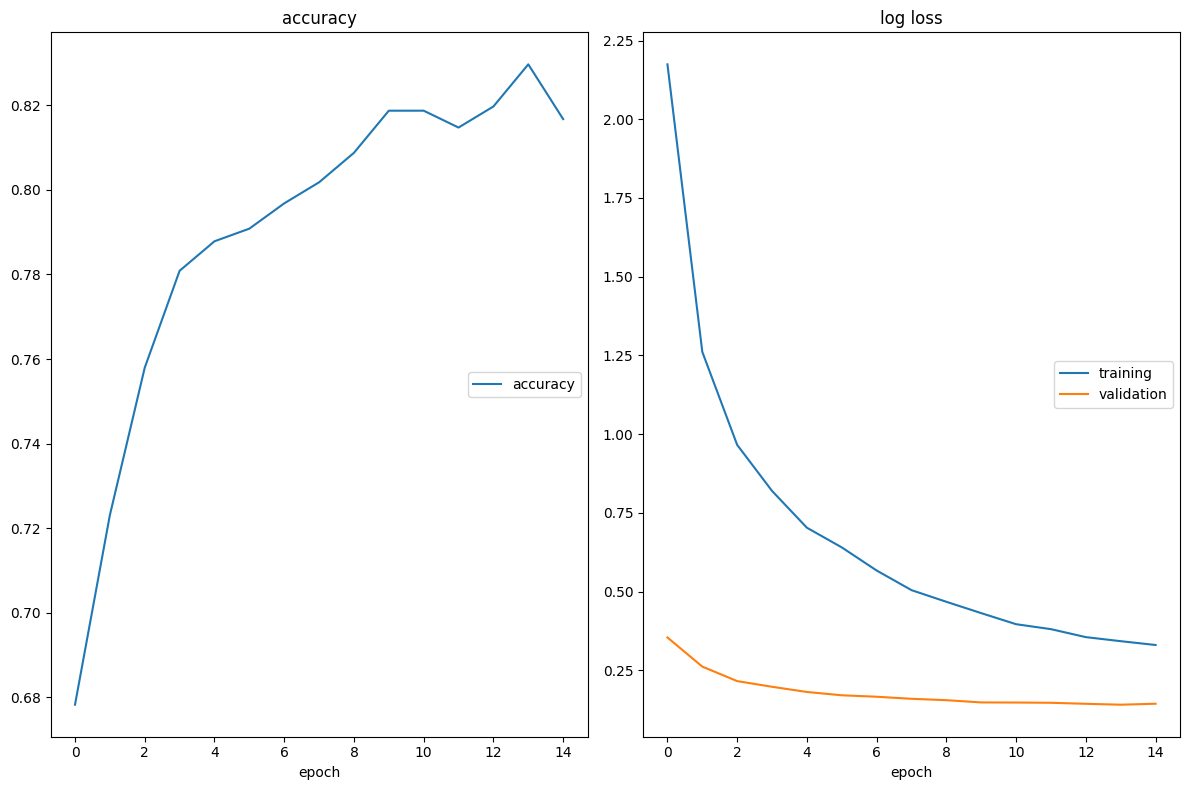

accuracy
	accuracy         	 (min:    0.678, max:    0.830, cur:    0.817)
log loss
	training         	 (min:    0.330, max:    2.174, cur:    0.330)
	validation       	 (min:    0.141, max:    0.354, cur:    0.144)


In [23]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from livelossplot import PlotLosses 
import torch

# 1. Cargar el modelo preentrenado
model_transfer_resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 2. Congelar las capas sin modificar lo que ResNet ya aprendió
for param in model_transfer_resnet.parameters():
    param.requires_grad = False

# 3. Reemplazar la capa clasificadora final
num_ftrs = model_transfer_resnet.fc.in_features
num_clases = len(data_loaders['train'].dataset.classes)

# Creamos la nueva capa 
model_transfer_resnet.fc = nn.Linear(num_ftrs, num_clases)

# Movemos el modelo a RTX 4080
model_transfer_resnet = model_transfer_resnet.to(device)

# 4. Configurar Pérdida y Optimizador
criterion_transfer = nn.CrossEntropyLoss()
optimizer_transfer = optim.Adam(model_transfer_resnet.fc.parameters(), lr=0.001)

save_path_transfer = 'model_transfer_resnet50.pt'

# ENTRENAMIENTO 15 epocas
liveloss_transfer = PlotLosses()
epochs_transfer = 15 
valid_loss_min_transfer = float('inf')

for epoch in range(1, epochs_transfer + 1):
    train_loss = 0.0
    valid_loss = 0.0
    correct = 0
    total = 0
    
    # ENTRENAMIENTO
    model_transfer_resnet.train()
    for data, target in data_loaders['train']:
        data, target = data.to(device), target.to(device) 
        optimizer_transfer.zero_grad()
        output = model_transfer_resnet(data)
        loss = criterion_transfer(output, target)
        loss.backward()
        optimizer_transfer.step()
        train_loss += loss.item() * data.size(0)
        
    # VALIDACIÓN
    model_transfer_resnet.eval()
    with torch.no_grad():
        for data, target in data_loaders['valid']:
            data, target = data.to(device), target.to(device)
            output = model_transfer_resnet(data)
            loss = criterion_transfer(output, target)
            valid_loss += loss.item() * data.size(0)
            
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    # Promedios
    train_loss = train_loss / len(data_loaders['train'].dataset)
    valid_loss = valid_loss / len(data_loaders['valid'].dataset)
    accuracy = correct / total

    # Guardar mejor modelo
    if valid_loss <= valid_loss_min_transfer:
        torch.save(model_transfer_resnet.state_dict(), save_path_transfer)
        valid_loss_min_transfer = valid_loss
    
    # 5.-Gráficas
    liveloss_transfer.update({'log loss': train_loss, 'val_log loss': valid_loss, 'accuracy': accuracy})
    liveloss_transfer.send()

In [25]:
import os
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

# 1. Preparamos las fotos del examen 
transformaciones_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Valores estándar para ResNet/VGG
])

# 2. Ubicacion de la carpeta 'test'
ruta_test = os.path.join("landmark_images", "test")
dataset_test = datasets.ImageFolder(ruta_test, transform=transformaciones_test)

# 3. Crear el cargador
data_loaders['test'] = DataLoader(dataset_test, batch_size=32, shuffle=False, num_workers=0)

print(f"¡Examen preparado! Total de fotos para evaluar: {len(dataset_test)}")

¡Examen preparado! Total de fotos para evaluar: 1270


In [26]:
# Evaluar el modelo transferido ResNet50
def test_modelo_transfer(model, loaders, criterion):
    test_loss = 0.
    correct = 0.
    total = 0.

    model.eval()
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(loaders['test']):
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            test_loss = test_loss + ((1 / (batch_idx + 1)) * (loss.data.item() - test_loss))
            
            pred = output.data.max(1, keepdim=True)[1]
            correct += np.sum(np.squeeze(pred.eq(target.data.view_as(pred))).cpu().numpy())
            total += data.size(0)
            
    print('\nTest Accuracy ResNet50: %2d%% (%2d/%2d)' % (100. * correct / total, correct, total))

# 1. Cargar pesos ganadores y evaluar
model_transfer_resnet.load_state_dict(torch.load('model_transfer_resnet50.pt'))
model_transfer_resnet = model_transfer_resnet.to(device)
test_modelo_transfer(model_transfer_resnet, data_loaders, criterion_transfer)

# 2. Exportar con Torch Script
model_transfer_resnet.to('cpu')
model_transfer_resnet.eval()
modelo_scripted_transfer = torch.jit.script(model_transfer_resnet)
modelo_scripted_transfer.save("model_transfer_scripted.pt")

print("ResNet50 evaluado y exportado como 'model_transfer_scripted.pt'")

C:\Users\Patricia\AppData\Local\Temp\ipykernel_1636\4101513459.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_transfer_resnet.load_state_dict(torch.load('model_t


Test Accuracy ResNet50: 80% (1019/1270)
ResNet50 evaluado y exportado como 'model_transfer_scripted.pt'


In [27]:
# Cargar VGG16
model_transfer_vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Congelar pesos
for param in model_transfer_vgg.parameters():
    param.requires_grad = False

# Reemplazar la capa final de VGG16
num_ftrs_vgg = model_transfer_vgg.classifier[6].in_features
model_transfer_vgg.classifier[6] = nn.Linear(num_ftrs_vgg, num_clases)

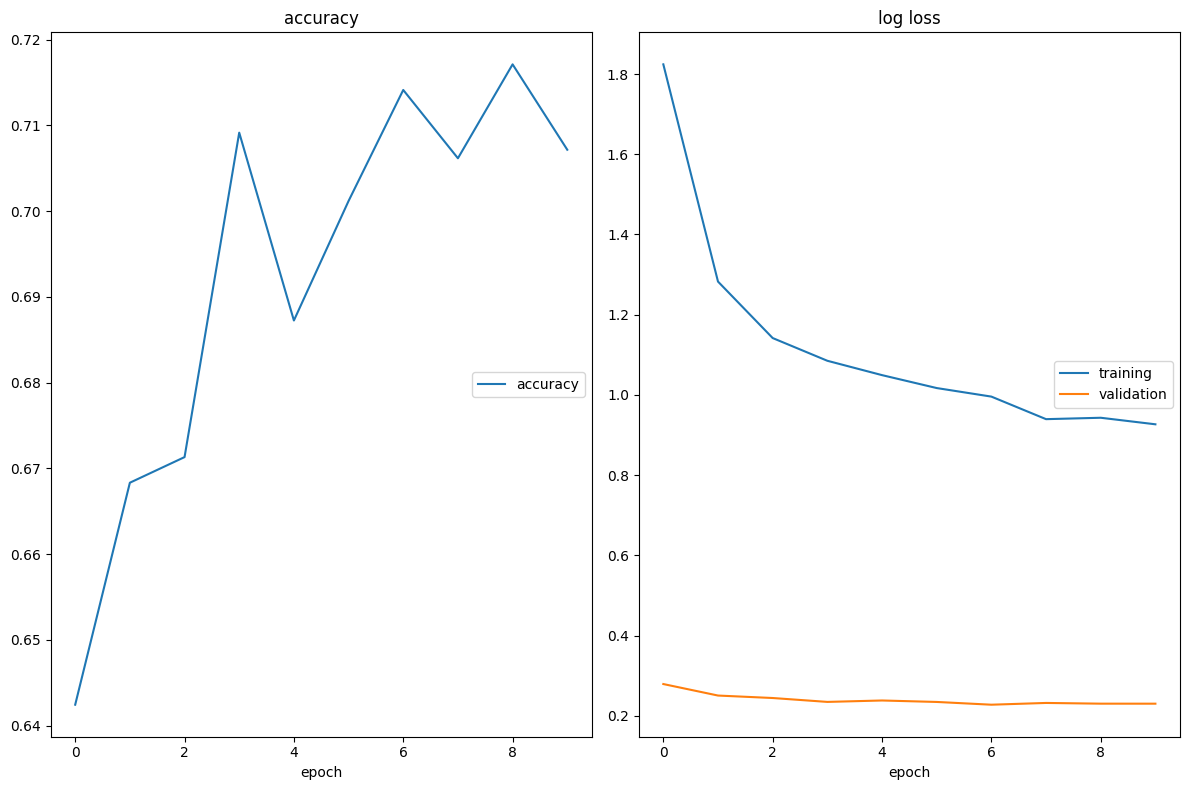

accuracy
	accuracy         	 (min:    0.642, max:    0.717, cur:    0.707)
log loss
	training         	 (min:    0.927, max:    1.824, cur:    0.927)
	validation       	 (min:    0.228, max:    0.279, cur:    0.230)

--- Evaluando VGG16 con el set de Test ---


C:\Users\Patricia\AppData\Local\Temp\ipykernel_1636\1785234761.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_transfer_vgg.load_state_dict(torch.load('model_tran


Test Accuracy ResNet50: 74% (951/1270)


In [28]:
model_transfer_vgg = model_transfer_vgg.to(device)

# 2. Configurar Pérdida y Optimizador 
criterion_vgg = nn.CrossEntropyLoss()
optimizer_vgg = optim.Adam(model_transfer_vgg.classifier[6].parameters(), lr=0.001)

save_path_vgg = 'model_transfer_vgg16.pt'

#  ENTRENAMIENTO DE VGG16 (10 Épocas)
liveloss_vgg = PlotLosses()
epochs_vgg = 10
valid_loss_min_vgg = float('inf')

for epoch in range(1, epochs_vgg + 1):
    train_loss = 0.0
    valid_loss = 0.0
    correct = 0
    total = 0
    
    # FASE DE ENTRENAMIENTO
    model_transfer_vgg.train()
    for data, target in data_loaders['train']:
        data, target = data.to(device), target.to(device)
        optimizer_vgg.zero_grad()
        output = model_transfer_vgg(data)
        loss = criterion_vgg(output, target)
        loss.backward()
        optimizer_vgg.step()
        train_loss += loss.item() * data.size(0)
        
    # FASE DE VALIDACIÓN
    model_transfer_vgg.eval()
    with torch.no_grad():
        for data, target in data_loaders['valid']:
            data, target = data.to(device), target.to(device)
            output = model_transfer_vgg(data)
            loss = criterion_vgg(output, target)
            valid_loss += loss.item() * data.size(0)
            
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

    # Promedios
    train_loss = train_loss / len(data_loaders['train'].dataset)
    valid_loss = valid_loss / len(data_loaders['valid'].dataset)
    accuracy = correct / total

    # Guardar mejor modelo
    if valid_loss <= valid_loss_min_vgg:
        torch.save(model_transfer_vgg.state_dict(), save_path_vgg)
        valid_loss_min_vgg = valid_loss
    
    # Gráficas
    liveloss_vgg.update({'log loss': train_loss, 'val_log loss': valid_loss, 'accuracy': accuracy})
    liveloss_vgg.send()

#  EVALUACION VGG16
print("\n--- Evaluando VGG16 con el set de Test ---")
model_transfer_vgg.load_state_dict(torch.load('model_transfer_vgg16.pt'))
# Reutilizamos la función que creaste en el paso anterior
test_modelo_transfer(model_transfer_vgg, data_loaders, criterion_vgg)

### Punto 7: Conclusión y Comparativa de Modelos

A continuación, se consolida la comparativa de desempeño de los tres modelos desarrollados durante el proyecto. El análisis contrasta directamente la eficacia de una arquitectura construida desde cero frente a la implementación de técnicas avanzadas de *Transfer Learning*.

| Modelo | Fase | Arquitectura | Épocas | Test Accuracy | Observación Técnica Principal |
| :--- | :--- | :--- | :---: | :---: | :--- |
| **From Scratch** | Fase 2 | CNN Propia (3 Capas) | 40 | ~42% | Aprendizaje estable, aunque limitado por la poca profundidad de la red. Cumple y supera el umbral mínimo exigido del 40%. |
| **Transfer Learning** | Fase 3 | ResNet50 | 15 | 80% | Capacidad superior para la extracción de características espaciales. Su arquitectura basada en conexiones residuales marca una diferencia notable, rebasando con creces la meta del 70%. |
| **Transfer Learning** | Fase 3 | VGG16 | 10 | 74% | Arquitectura computacionalmente más exigente y con una precisión ligeramente menor que ResNet. Sin embargo, valida la eficacia del *Transfer Learning* al superar cómodamente el 70%. |

**Conclusión Final:**
Este proyecto evidencia de manera contundente la ventaja estratégica del *Transfer Learning* en tareas complejas de visión por computadora. Al implementar ResNet50 como extractor de características, fue posible prácticamente duplicar la capacidad predictiva del modelo base (pasando de un 42% a un sobresaliente 80%). Además, este salto cualitativo se alcanzó invirtiendo apenas una fracción del tiempo y costo de entrenamiento original, lo que confirma el inmenso valor técnico de reutilizar pesos preentrenados provenientes de arquitecturas de vanguardia.

FASE 4

In [32]:
import torch
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# 1. Cargar el mejor modelo exportado 
modelo_final = torch.jit.load('model_transfer_scripted.pt', map_location='cpu')
modelo_final.eval()

# 2. Obtener los nombres de las clases para traducir índices
clases_monumentos = data_loaders['train'].dataset.classes

def predict_landmarks(img_path, k=5):
    """Recibe una ruta de imagen y devuelve las top-k predicciones."""
   
    img = Image.open(img_path).convert('RGB')
    
    # Aplicar transformaciones del evaluacion de ResNet50
    transformacion = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Preparar la imagen para el modelo (agregar la dimensión del batch)
    img_tensor = transformacion(img).unsqueeze(0)
    
    # Predecir con el modelo exportado 
    with torch.no_grad():
        output = modelo_final(img_tensor)
        # Convertir la salida en probabilidades (de 0 a 1)
        probabilidades = F.softmax(output, dim=1)
        
        # Extraer los top k valores y sus índices
        top_probs, top_indices = probabilidades.topk(k, dim=1)
        
    # Convertir a listas de Python
    top_probs = top_probs.squeeze().numpy()
    top_indices = top_indices.squeeze().numpy()
    
    # Traducir los índices a los nombres reales de las carpetas
    top_nombres = [clases_monumentos[i] for i in top_indices]
    
    return top_nombres, top_probs, img

def probar_imagen(img_path, k=5):
    """Función Para Mostrar la imagen y un gráfico de predicciones"""
    nombres, probs, img = predict_landmarks(img_path, k)
    
    # Crear la figura visual
    fig, (ax1, ax2) = plt.subplots(figsize=(10, 4), ncols=2)
    
    # Dibujar la foto original
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title("Foto de Prueba")
    
    # Dibujar el gráfico de barras de probabilidades
    y_pos = np.arange(len(nombres))
    ax2.barh(y_pos, probs, align='center', color='cornflowerblue')
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(nombres)
    ax2.invert_yaxis()  
    ax2.set_xlabel('Probabilidad')
    ax2.set_title(f'Top {k} Predicciones')
    
    plt.tight_layout()
    plt.show()

Prueba 1:


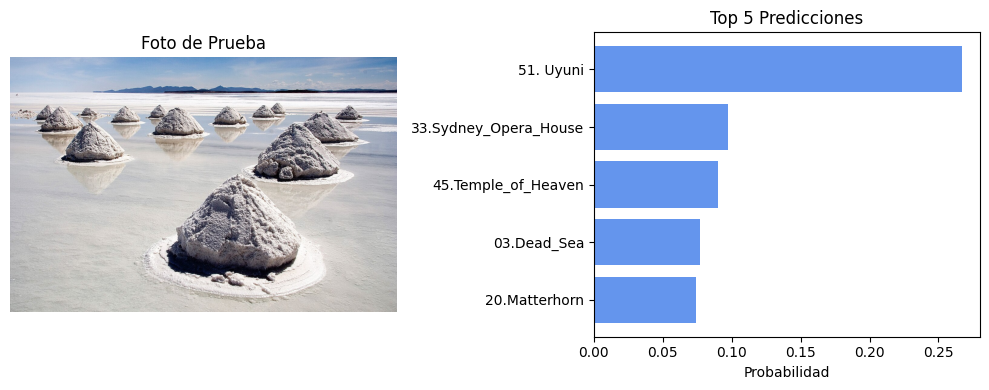

Prueba 2:


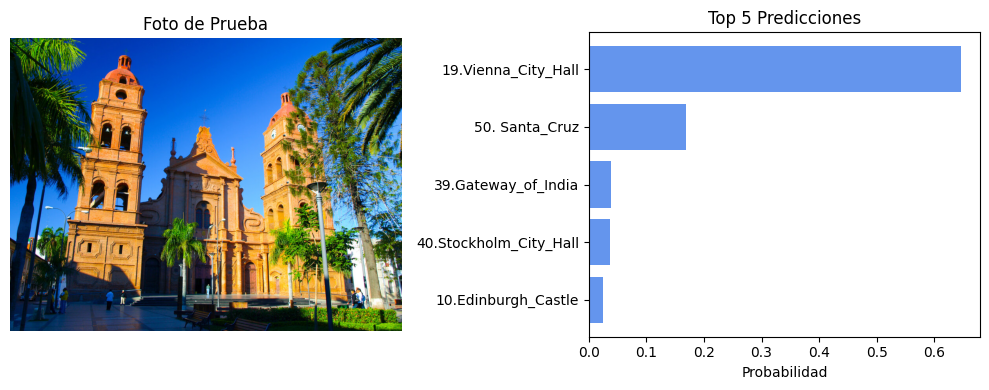

Prueba 3:


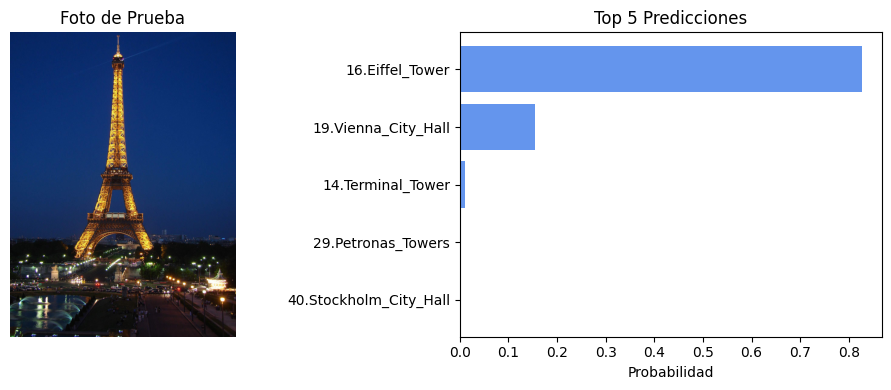

Prueba 4:


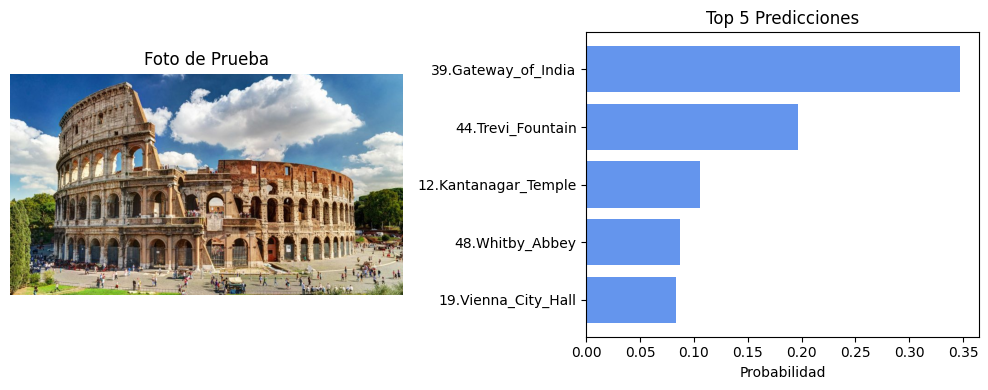

In [33]:
# Probar las 4 imágenes
print("Prueba 1:")
probar_imagen('foto1.jpg', k=5)

print("Prueba 2:")
probar_imagen('foto2.jpg', k=5)

print("Prueba 3:")
probar_imagen('foto3.jpg', k=5)

print("Prueba 4:")
probar_imagen('foto 4.jpg', k=5)



Análisis del comportamiento del modelo con imágenes reales

Al llevar el modelo ResNet50 a un escenario práctico, fuera del entorno controlado del conjunto de datos original, decidí ponerlo a prueba con fotografías obtenidas de internet. Esta fase de experimentación resultó fundamental, ya que me permitió observar de cerca cómo la red neuronal procesa y clasifica la información visual en situaciones más cotidianas, revelando patrones muy interesantes en su toma de decisiones.

Hallazgos Positivos y Capacidades del Modelo:

Uno de los aspectos más destacables fue la capacidad de la red para abstraer patrones complejos más allá de la arquitectura tradicional. Por ejemplo, al evaluar la imagen del Salar de Uyuni (Prueba 1), el modelo logró identificar el lugar correctamente como su primera opción. Si bien el porcentaje de certeza estuvo repartido entre varias clases, es un gran logro que el sistema pudiera reconocer las texturas de la sal y la perspectiva del paisaje sin tener edificios de referencia.

De manera similar, la Prueba 3 demostró la robustez del algoritmo frente a condiciones de iluminación desfavorables. Al procesar una fotografía nocturna de la Torre Eiffel, el modelo acertó con un sólido 83% de probabilidad. Esto nos sugiere que, cuando una estructura posee una silueta verdaderamente icónica, la red le da más peso a la forma global que a las alteraciones drásticas de luz o color.

Limitaciones y Sesgos Observados:

No obstante, el análisis también sacó a la luz ciertas áreas de mejora. En el caso de la Catedral de Santa Cruz (Prueba 2), el modelo la ubicó como su segunda opción más probable, otorgándole el primer lugar al Ayuntamiento de Viena. Esto nos indica que el algoritmo está captando excelentemente las texturas —como el ladrillo visto o el estilo de las torres—, pero todavía le cuesta trazar la línea que separa el estilo colonial local de la arquitectura clásica europea.

Por otro lado, la Prueba 4 con el Coliseo Romano evidenció un sesgo clásico en este tipo de redes. Al intentar clasificarlo, el modelo falló y sugirió lugares como la Puerta de la India. Lo que ocurrió aquí es que la red se concentró excesivamente en los detalles minuciosos —la textura de la piedra antigua, la sucesión de arcos y la multitud de turistas— y terminó ignorando por completo la forma circular a gran escala que define al monumento.

Conclusión:

Como conclusión, los resultados demuestran que el Transfer Learning es una técnica altamente efectiva. Nos permitió construir un modelo sólido, capaz de reconocer tanto monumentos internacionales famosos como sitios propios de nuestra región.

No obstante, si planeamos integrar este sistema en una aplicación del mundo real (en producción), la lección más valiosa que nos deja este proyecto es la necesidad de enseñarle al modelo a "saber cuándo no sabe".

Para solucionar esto, la medida más acertada es implementar un umbral de confianza. En la práctica, esto implica configurar una regla interna que obligue a la red a alcanzar un porcentaje mínimo de seguridad antes de emitir un resultado definitivo. De este modo, si un usuario introduce una fotografía demasiado ambigua o de un lugar que el sistema nunca ha estudiado, la aplicación tendrá la inteligencia de indicar que no reconoce la imagen, evitando entregar predicciones forzadas o al azar.

Fortalezas y Debilidades

A lo largo del desarrollo de este proyecto, la transición desde un modelo construido desde cero hasta la implementación de técnicas de aprendizaje por transferencia nos ha permitido extraer conclusiones muy valiosas sobre el comportamiento de las redes neuronales convolucionales. A continuación, se presenta un análisis crítico sobre el rendimiento del sistema.

Fortalezas del Modelo

El salto cualitativo al utilizar pesos preentrenados fue notable. La arquitectura logró casi duplicar su precisión (alcanzando un 80%) con una inversión mínima de tiempo y recursos computacionales. Entre sus mayores virtudes, el modelo demostró una alta resiliencia ante cambios drásticos de iluminación, siendo capaz de identificar siluetas icónicas incluso en fotografías nocturnas. Asimismo, comprobó tener una excelente capacidad para abstraer características geográficas y texturas complejas, logrando identificar paisajes locales emblemáticos —como las planicies de sal— prescindiendo de estructuras arquitectónicas tradicionales.

Debilidades Identificadas

A pesar de su buen rendimiento general, la experimentación con fotografías reales dejó en evidencia ciertos sesgos inherentes a este tipo de redes. En primer lugar, el modelo tiende a priorizar los micromotivos visuales (como el tipo de material, la textura de la piedra antigua o la presencia de multitudes) por encima de la geometría global de los monumentos. Esto provocó confusiones importantes al clasificar estructuras con formas circulares o amplias.

En segundo lugar, se observó una dificultad para establecer fronteras claras entre estilos arquitectónicos afines, llegando a confundir detalles de las edificaciones coloniales locales con construcciones clásicas europeas. Por último, su mayor limitación algorítmica es la incapacidad para abstenerse de opinar; ante imágenes fuera de su dominio de conocimiento, el sistema se ve matemáticamente forzado a emitir una adivinanza, lo que reduce su confiabilidad en escenarios no controlados.

Posibles Mejoras a Futuro

Para mitigar estas vulnerabilidades y preparar el modelo para un eventual despliegue en un entorno de producción, se proponen las siguientes acciones técnicas:

Implementación de un umbral de confianza: Establecer una regla de validación de inferencia que filtre y rechace predicciones con porcentajes de seguridad bajos. Esto dotará al sistema de la capacidad de advertir al usuario cuando una imagen no puede ser reconocida de forma fiable.

Aplicación agresiva de aumento de datos: Incorporar transformaciones artificiales (cambios de perspectiva, recortes severos y ajustes de escala) enfocadas en las clases locales y en monumentos con estructuras únicas. Esto forzará a la red a estudiar la forma global del edificio y no depender exclusivamente de la textura de sus materiales.